# Proyecto de Machine Learning: Bank Marketing
## Baseline Inicial: Carga, Auditoría y Exploración de Datos

**Objetivo del Negocio**: Nos enfrentamos a un problema de clasificación binaria. El objetivo principal es predecir si un cliente aceptará o no un depósito a término fijo (variable objetivo `y`). 

**Acerca de este Notebook**: 
Este documento sirve como un **baseline robusto y reproducible** para la ingesta de datos, la revisión analítica (EDA) y la verificación de calidad de los datos. Está estructurado de forma secuencial, inspirado en metodologías probadas (como `ml_machinelearninglandscape`).


---
## 1. Setup Reproducible
Configuración inicial del entorno. Asegurando que los gráficos, las semillas y las configuraciones de pandas sean constantes a lo largo del análisis.

In [46]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

# Configuración Visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Opciones de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("✅ Entorno configurado de manera reproducible.")


✅ Entorno configurado de manera reproducible.


---
## 2. Helper Functions
Funciones que nos permiten auditar el dataset de forma rápida, visualizar y no repetir código.

In [47]:
def print_section(title: str, width: int = 88) -> None:
    """Imprime un separador de sección visual."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def summarize_missingness(df):
    """Muestra conteo y porcentaje de nulos nativos."""
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    missing_pct = (missing_data / len(df)) * 100
    
    if missing_pct.empty:
        print("✅ No hay valores nulos detectables nativamente ('NaN') en el DataFrame.")
    else:
        missing_df = pd.DataFrame({'Missing_Values': missing_data, 'Percentage': missing_pct}).sort_values(by='Percentage', ascending=False)
        display(missing_df)
        
def plot_target_distribution(df, target_col):
    """Grafica la distribución visual de la variable objetivo."""
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='viridis')
    plt.title("Distribución de la Variable Objetivo")
    plt.show()
    
    counts = df[target_col].value_counts(normalize=True) * 100
    print(f"\nPorcentaje por clase:\n{counts}")

def plot_correlation_heatmap(df):
    """Matriz de correlación rápida para variables numéricas."""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    corr = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=.5)
    plt.title("Matriz de Correlación de Variables Numéricas")
    plt.show()


---
## 3. Carga del Dataset
Importamos el dataset desde [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) usando la biblioteca `ucimlrepo`.

**Nota metodológica sobre la estructura UCI**: Este repositorio entrega los datos separados en dos bloques clave desde el origen:
- **`features` (X)**: Las variables independientes que el modelo usará para aprender (edad, trabajo, balance, etc).
- **`targets` (y)**: La variable objetivo que queremos predecir (en este caso, `y`: si el cliente aceptó o no el depósito).

Nosotros sabemos desde el inicio cuál es nuestro `target`. Sin embargo, aquí las cargaremos y formaremos un **único DataFrame temporal (`df`)** exclusivamente para aprovechar la etapa visual y auditar cómo interaccionan las características contra la variable objetivo. Más adelante se volverán a tratar por separado para evitar el Data Leakage.

In [48]:
from ucimlrepo import fetch_ucirepo

print("Descargando el dataset 'Bank Marketing' (ID 222)...")
try:
    bank_marketing = fetch_ucirepo(id=222)
    
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    
    # DataFrame consolidado únicamente para el EDA
    df = pd.concat([X, y], axis=1)
    
    print(f"✅ ¡Dataset cargado! Dimensión: {df.shape[0]:,} filas y {df.shape[1]} columnas.")
except Exception as e:
    raise RuntimeError(f"No fue posible cargar el dataset Bank Marketing desde UCI: {e}") from e


Descargando el dataset 'Bank Marketing' (ID 222)...
✅ ¡Dataset cargado! Dimensión: 45,211 filas y 17 columnas.


---
## 4. Auditoría Temprana y Calidad de Datos
Revisaremos tipos de datos, estadísticas básicas, valores nulos, cardinalidades inusuales y registros duplicados.

In [49]:
print_section("VISTA RÁPIDA DE LOS DATOS")
display(df.head())



                               VISTA RÁPIDA DE LOS DATOS                                


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [50]:
print_section("INFORMACIÓN DEL ESQUEMA")
df.info()



                                INFORMACIÓN DEL ESQUEMA                                 
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


### 4.1. Descripción Numérica Rápida
Observaremos medias, medianas, deciles/cuartiles y valores atípicos evidentes analizando los mínimos y máximos.

In [51]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day_of_week,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


### 4.2. Cardinalidad y Duplicados
Revisemos si hay variables de alta cardinalidad o registros exactamente duplicados (común en encuestas sin ID único).

In [52]:
print_section("CARDINALIDAD POR VARIABLE")
cardinality = df.nunique().sort_values()
display(cardinality)

print_section("DUPLICADOS ESTRUCTURALES")
duplicados = df.duplicated().sum()
pct_duplicados = (duplicados / len(df)) * 100
print(f"El dataset contiene {duplicados:,} filas duplicadas ({pct_duplicados:.2f}%)")



                               CARDINALIDAD POR VARIABLE                                


contact           2
loan              2
housing           2
default           2
y                 2
marital           3
poutcome          3
education         3
job              11
month            12
day_of_week      31
previous         41
campaign         48
age              77
pdays           559
duration       1573
balance        7168
dtype: int64


                                DUPLICADOS ESTRUCTURALES                                
El dataset contiene 0 filas duplicadas (0.00%)


### 4.3. Valores Faltantes (Explícitos e Implícitos)
Algunos datasets suele guardar los faltantes como la categoría `"unknown"`, además de los clásicos `NaN`.


In [53]:
# Revisión de Nulos Nativos
print_section("NULOS NATIVOS DE PANDAS")
summarize_missingness(df)



                                NULOS NATIVOS DE PANDAS                                 


,Missing_Values,Percentage
poutcome,36959,81.748
contact,13020,28.798
education,1857,4.107
job,288,0.637


In [54]:
# Revisión de faltantes categóricos reales entregados por ucimlrepo
print_section("FALTANTES CATEGÓRICOS INTERPRETADOS")

categorical_missing = df.select_dtypes(include=['object', 'string']).isna().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

if categorical_missing.empty:
    print("No hay faltantes en variables categóricas.")
else:
    missing_interpretation = pd.DataFrame({
        "missing_values": categorical_missing,
        "percentage": categorical_missing / len(df) * 100,
        "decision_preprocesamiento": [
            "crear categoría 'missing' o indicador; no descartar por alta proporción" if col in ["poutcome", "contact"] else "imputar con moda o categoría 'missing'"
            for col in categorical_missing.index
        ]
    })
    display(missing_interpretation)



                          FALTANTES CATEGÓRICOS INTERPRETADOS                           


,missing_values,percentage,decision_preprocesamiento
poutcome,36959,81.748,crear categoría 'missing' o indicador; no desc...
contact,13020,28.798,crear categoría 'missing' o indicador; no desc...
education,1857,4.107,imputar con moda o categoría 'missing'
job,288,0.637,imputar con moda o categoría 'missing'


### Conclusiones sobre Calidad de Datos

- El conjunto de datos está compuesto por **45.211 observaciones** y **17 variables**, y no presenta duplicados estructurales exactos. Este hallazgo sugiere que no existe evidencia inmediata para aplicar una depuración inicial basada en la eliminación de registros repetidos, por lo que el análisis puede continuar preservando la totalidad de las observaciones disponibles.

- La variable `balance` constituye uno de los principales retos de calidad y preparación de datos dentro del estudio. Su distribución exhibe una **asimetría positiva pronunciada**, una diferencia considerable entre media y mediana, presencia de **valores negativos** y una cola derecha extensa con observaciones extremas. Desde una perspectiva estadística, este comportamiento indica que la variable se aparta de los supuestos de simetría o normalidad que favorecen a ciertos algoritmos y procedimientos de escalado convencionales.

- En este contexto, resulta metodológicamente razonable considerar transformaciones que reduzcan la asimetría y atenúen la influencia de los valores extremos. Una alternativa particularmente pertinente es `PowerTransformer(method="yeo-johnson")`, dado que esta transformación admite valores negativos y puede aproximar la distribución a una forma más regular sin necesidad de excluir observaciones. De manera complementaria, la winsorización controlada constituye otra estrategia válida, en la medida en que limita el efecto de las observaciones extremas mediante el recorte de percentiles, preservando al mismo tiempo el tamaño muestral. No obstante, la adopción de cualquiera de estas técnicas debe justificarse empíricamente a través de la comparación de desempeño entre modelos, y no únicamente a partir de criterios descriptivos.

- La variable `pdays` requiere una interpretación cuidadosa, ya que el valor `-1` no representa una magnitud temporal real, sino un código sentinela que indica ausencia de contacto previo con el cliente. Tratar este valor como si formara parte de una escala numérica continua introduciría una distorsión conceptual y estadística. Por ello, una estrategia más consistente consiste en descomponer la información en dos componentes: una variable indicadora de contacto previo y una versión de `pdays` en la que `-1` sea reemplazado por `NaN`, permitiendo así una imputación posterior coherente dentro del pipeline.

- En relación con los valores faltantes, el dataset presenta ausencias relevantes principalmente en variables categóricas como `poutcome`, `contact`, `education` y `job`. La magnitud de los faltantes es especialmente alta en `poutcome` y significativa en `contact`, lo que sugiere que la ausencia de información podría no ser completamente aleatoria. Bajo esta consideración, imputar mediante una categoría explícita como `missing` constituye una decisión metodológicamente defendible, ya que conserva la totalidad de los registros y permite que el modelo capture la posible señal asociada al patrón de ausencia.

- Finalmente, la variable `duration` debe interpretarse con precaución en términos de validez predictiva. Aunque posee un valor descriptivo claro dentro del análisis exploratorio, su incorporación en un modelo orientado a predicción **pre-contacto** implicaría una forma de **data leakage**, dado que su valor solo es conocido durante o después de la interacción telefónica. En consecuencia, esta variable puede contribuir a la comprensión del fenómeno en el EDA, pero debe excluirse del pipeline de modelado si se pretende construir un sistema predictivo alineado con un escenario operativo realista.


---
## 4.4. Preparación de Datos

A partir de la revisión de calidad, se agregan controles concretos para dejar el dataset listo para el preprocesamiento: revisar la asimetría y outliers de `balance`, transformar correctamente el sentinela `pdays=-1`, definir cómo imputar los faltantes reales (`NaN`) y asegurar que `duration` quede fuera de las variables candidatas por ser una fuente de data leakage.


### 4.4.1. Diagnóstico accionable de `balance`

La variable `balance` se analiza de forma específica porque su distribución no es regular: presenta valores negativos, una cola derecha muy larga y valores extremos que pueden afectar el preprocesamiento y el comportamiento de algunos modelos. Por esta razón, antes de decidir cómo tratarla en el pipeline, conviene cuantificar mejor su forma y su nivel de dispersión.

Este diagnóstico se realiza para entender si la variable necesita un tratamiento especial en etapas posteriores. En particular, permite evaluar si la asimetría y los outliers pueden distorsionar estadísticas como la media, afectar el escalado y volver menos estable el entrenamiento de modelos sensibles a la magnitud de las variables.

Para ello se revisan cuantiles, asimetría, proporción de valores negativos y porcentaje de observaciones fuera de los límites definidos por IQR. Además, se explora una transformación `signed_log1p`, que comprime valores extremos manteniendo el signo de la variable. Esta transformación no se aplica todavía al dataset final; se usa solo como herramienta de diagnóstico para visualizar mejor la estructura de `balance`.

Con este análisis se logra justificar por qué `balance` podría requerir un tratamiento distinto al resto de variables numéricas. También deja planteadas alternativas como `PowerTransformer(method="yeo-johnson")`, `RobustScaler` o winsorización, que podrán compararse más adelante dentro del proceso de modelado.

La concentración observada alrededor de `0` también es relevante. Esta puede deberse a dos causas: que existan muchos clientes con `balance` exactamente igual a cero, o que haya una gran cantidad de saldos pequeños cercanos a cero. En la escala transformada esta concentración se ve aún más marcada, porque `signed_log1p` aproxima entre sí los valores de baja magnitud. Por ello, conviene medir explícitamente cuántos registros tienen `balance = 0` y cuántos se concentran en un rango pequeño alrededor de ese valor.


In [55]:
balance_q = df["balance"].quantile([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
balance_iqr = balance_q.loc[0.75] - balance_q.loc[0.25]
balance_upper_fence = balance_q.loc[0.75] + 1.5 * balance_iqr
balance_lower_fence = balance_q.loc[0.25] - 1.5 * balance_iqr

balance_profile = pd.DataFrame({
    "metric": [
        "mean",
        "median",
        "skewness",
        "negative_values_pct",
        "iqr_lower_fence",
        "iqr_upper_fence",
        "iqr_outliers_pct"
    ],
    "value": [
        df["balance"].mean(),
        df["balance"].median(),
        df["balance"].skew(),
        (df["balance"] < 0).mean() * 100,
        balance_lower_fence,
        balance_upper_fence,
        ((df["balance"] < balance_lower_fence) | (df["balance"] > balance_upper_fence)).mean() * 100
    ]
})

print_section("PERFIL DE BALANCE")
display(balance_q.rename("balance_quantiles").to_frame())
display(balance_profile)



                                   PERFIL DE BALANCE                                    


,balance_quantiles
0.000,"-8,019.000"
0.010,-627.000
0.050,-172.000
0.250,72.000
0.500,448.000
0.750,"1,428.000"
0.950,"5,768.000"
0.990,"13,164.900"
1.000,"102,127.000"


,metric,value
0,mean,"1,362.272"
1,median,448.000
2,skewness,8.360
3,negative_values_pct,8.330
4,iqr_lower_fence,"-1,962.000"
5,iqr_upper_fence,"3,462.000"
6,iqr_outliers_pct,10.460


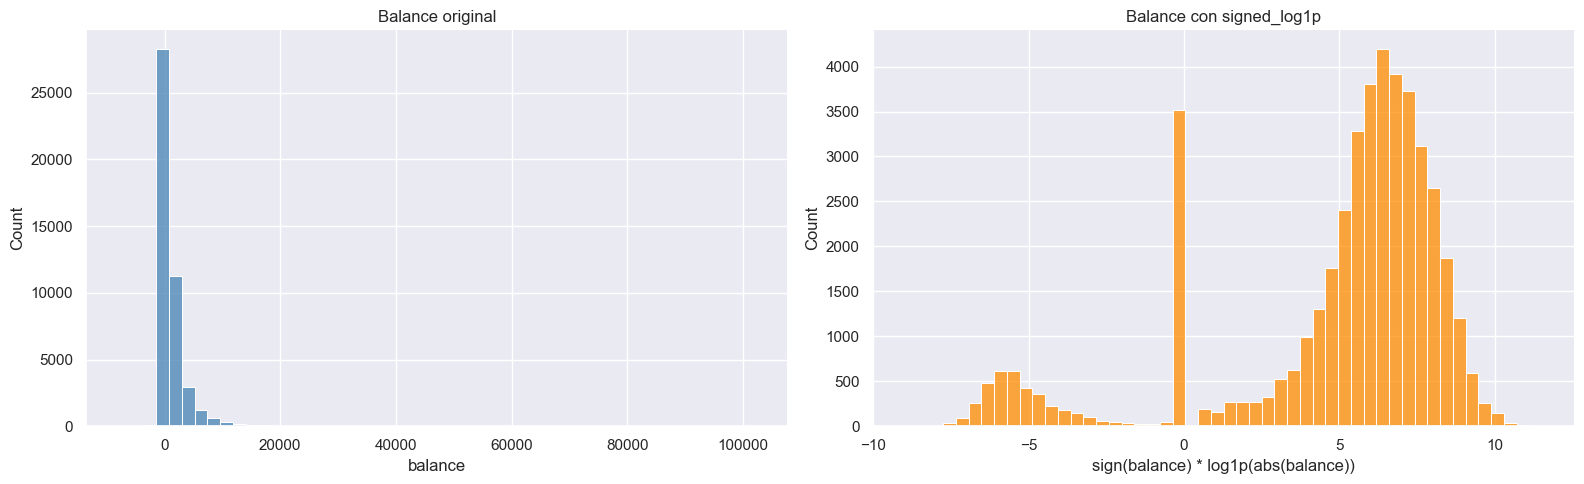

In [56]:
balance_signed_log = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["balance"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Balance original")
axes[0].set_xlabel("balance")

sns.histplot(balance_signed_log, bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Balance con signed_log1p")
axes[1].set_xlabel("sign(balance) * log1p(abs(balance))")

plt.tight_layout()
plt.show()


In [ ]:
zero_balance_summary = pd.DataFrame({
    "metric": [
        "exact_zero_count",
        "exact_zero_pct",
        "between_-50_and_50_count",
        "between_-50_and_50_pct"
    ],
    "value": [
        (df["balance"] == 0).sum(),
        (df["balance"] == 0).mean() * 100,
        df["balance"].between(-50, 50).sum(),
        df["balance"].between(-50, 50).mean() * 100
    ]
})

print_section("CONCENTRACION DE BALANCE CERCA DE 0")
display(zero_balance_summary)


Si la proporción de `balance = 0` es alta, entonces existe una acumulación real en ese punto. Si en cambio la proporción exacta en cero es menor, pero el porcentaje dentro del rango `[-50, 50]` es elevado, la concentración visual alrededor de `0` se explica mejor por la presencia de muchos saldos pequeños. Esta verificación ayuda a interpretar mejor la forma de la variable y a decidir si conviene aplicar transformaciones o escalados más robustos.


### 4.4.2. Tratamiento propuesto para `pdays=-1`

El valor `-1` en `pdays` no representa una cantidad temporal real, sino un código sentinela que indica que el cliente no había sido contactado previamente. Por esta razón, mantenerlo como si fuera un valor numérico ordinario introduciría una ambigüedad importante en el análisis y en el modelado, ya que el algoritmo podría interpretarlo como una distancia válida dentro de la escala de días.

Desde el punto de vista metodológico, reemplazar `-1` por `NaN` ofrece un beneficio claro: permite que el pipeline trate estos casos como ausencia de información temporal real, en lugar de forzar una interpretación numérica incorrecta. Esto evita que el modelo asuma relaciones artificiales entre `-1` y valores legítimos de `pdays`, como `1`, `5` o `30`, que sí representan días transcurridos desde un contacto previo.

Sin embargo, convertir `-1` en `NaN` no significa perder la señal contenida en esa condición. Para preservar esa información de negocio, se propone crear una variable binaria adicional, `was_previously_contacted`, que indique explícitamente si existió o no un contacto previo con el cliente. De esta forma, el problema original se descompone en dos señales más limpias y más interpretables:

- `was_previously_contacted`: captura la existencia de contacto previo.
- `pdays`: conserva únicamente la magnitud temporal cuando esa distancia realmente existe.

Esta estrategia aporta varias ventajas analíticas. En primer lugar, mejora la coherencia semántica de la variable, porque separa la ausencia de contacto de la noción de tiempo transcurrido. En segundo lugar, facilita una imputación posterior más razonable dentro del pipeline numérico. Finalmente, reduce el riesgo de que modelos sensibles a magnitudes interpreten `-1` como un valor cercano a cero, cuando en realidad representa una condición cualitativamente distinta.


In [57]:
pdays_action = pd.DataFrame({
    "metric": [
        "rows_without_previous_contact",
        "rows_without_previous_contact_pct",
        "rows_with_previous_contact",
        "rows_with_previous_contact_pct"
    ],
    "value": [
        (df["pdays"] == -1).sum(),
        (df["pdays"] == -1).mean() * 100,
        (df["pdays"] != -1).sum(),
        (df["pdays"] != -1).mean() * 100
    ]
})

pdays_preview = df[["pdays", "previous"]].copy()
pdays_preview["was_previously_contacted"] = (pdays_preview["pdays"] != -1).astype(int)
pdays_preview["pdays_clean"] = pdays_preview["pdays"].replace(-1, np.nan)

print_section("REGLA PROPUESTA PARA PDAYS")
display(pdays_action)
display(pdays_preview.head(10))



                               REGLA PROPUESTA PARA PDAYS                               


,metric,value
0,rows_without_previous_contact,"36,954.000"
1,rows_without_previous_contact_pct,81.737
2,rows_with_previous_contact,"8,257.000"
3,rows_with_previous_contact_pct,18.263


,pdays,previous,was_previously_contacted,pdays_clean
0,-1,0,0,NaN
1,-1,0,0,NaN
2,-1,0,0,NaN
3,-1,0,0,NaN
4,-1,0,0,NaN
5,-1,0,0,NaN
6,-1,0,0,NaN
7,-1,0,0,NaN
8,-1,0,0,NaN
9,-1,0,0,NaN


### 4.4.3. Plan de imputación para faltantes reales

Como `ucimlrepo` entrega los faltantes como `NaN`, el notebook debe documentar una acción por columna. La regla base será conservar el faltante como categoría `missing` en variables categóricas, especialmente donde la ausencia de información puede tener significado operativo.


In [58]:
missing_action_plan = pd.DataFrame({
    "column": ["poutcome", "contact", "education", "job"],
    "missing_pct": [df[col].isna().mean() * 100 for col in ["poutcome", "contact", "education", "job"]],
    "proposed_action": [
        "imputar como categoría 'missing'; no eliminar por alta proporción",
        "imputar como categoría 'missing'; ausencia de canal puede ser informativa",
        "imputar como categoría 'missing' o moda en experimentos posteriores",
        "imputar como categoría 'missing' o moda en experimentos posteriores"
    ],
    "reason": [
        "faltante masivo asociado a no tener resultado de campaña previa",
        "faltante relevante asociado al tipo de contacto disponible",
        "faltante bajo; conservar registros evita pérdida innecesaria de datos",
        "faltante bajo; conservar registros evita pérdida innecesaria de datos"
    ]
})

print_section("PLAN DE IMPUTACIÓN")
display(missing_action_plan.sort_values("missing_pct", ascending=False))



                                   PLAN DE IMPUTACIÓN                                   


,column,missing_pct,proposed_action,reason
0,poutcome,81.748,imputar como categoría 'missing'; no eliminar ...,faltante masivo asociado a no tener resultado ...
1,contact,28.798,imputar como categoría 'missing'; ausencia de ...,faltante relevante asociado al tipo de contact...
2,education,4.107,imputar como categoría 'missing' o moda en exp...,faltante bajo; conservar registros evita pérdi...
3,job,0.637,imputar como categoría 'missing' o moda en exp...,faltante bajo; conservar registros evita pérdi...


### 4.4.4. Control explícito de leakage por `duration`

`duration` se puede analizar en EDA para entender el comportamiento histórico, pero debe excluirse antes del split y del pipeline final. Esta celda deja una lista inicial de columnas candidatas y una aserción que falla si `duration` se cuela accidentalmente.


In [59]:
TARGET_COL = "y"
LEAKAGE_COLS = ["duration"]

candidate_feature_cols = [col for col in df.columns if col not in [TARGET_COL] + LEAKAGE_COLS]

assert "duration" not in candidate_feature_cols, "duration no debe entrar al pipeline de modelado pre-llamada"

print(f"Columnas candidatas para modelado: {len(candidate_feature_cols)}")
print(candidate_feature_cols)


Columnas candidatas para modelado: 15
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


---
## 5. EDA: Análisis Exploratorio de Datos
Veamos la relación gráfica de los elementos de negocio y las correlaciones para empezar a plantear el modelo mental previo a las transformaciones.

### 5.1. Distribución de la Clase Objetivo
Comprobemos qué tan desbalanceado está el target.

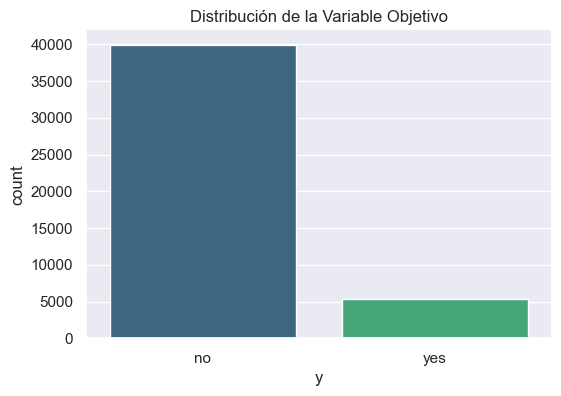


Porcentaje por clase:
y
no    88.302
yes   11.698
Name: proportion, dtype: float64


In [60]:
plot_target_distribution(df, "y")


### 5.2. Distribuciones Numéricas y Varianzas
Distribuciones generales y sesgos de variables cuantitativas.

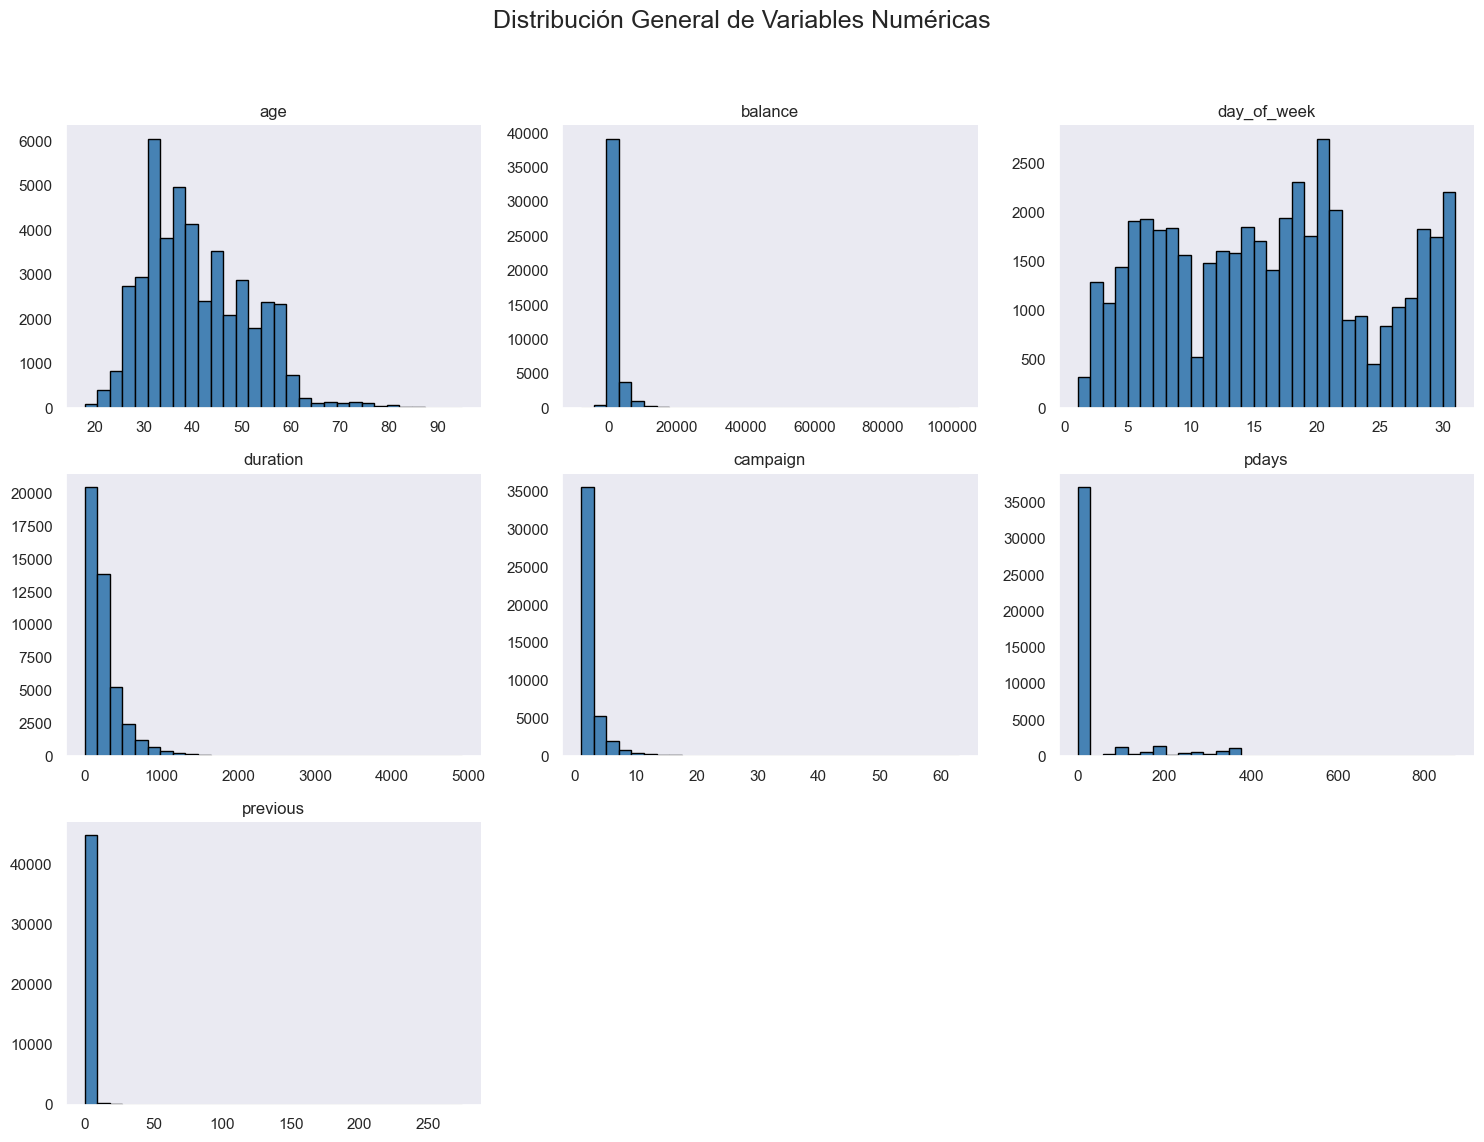

In [61]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 12), edgecolor='black', grid=False, color='steelblue')
plt.suptitle('Distribución General de Variables Numéricas', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 5.3. Interacción Bivariada y Leakage
Contraste numérico vs aceptación.

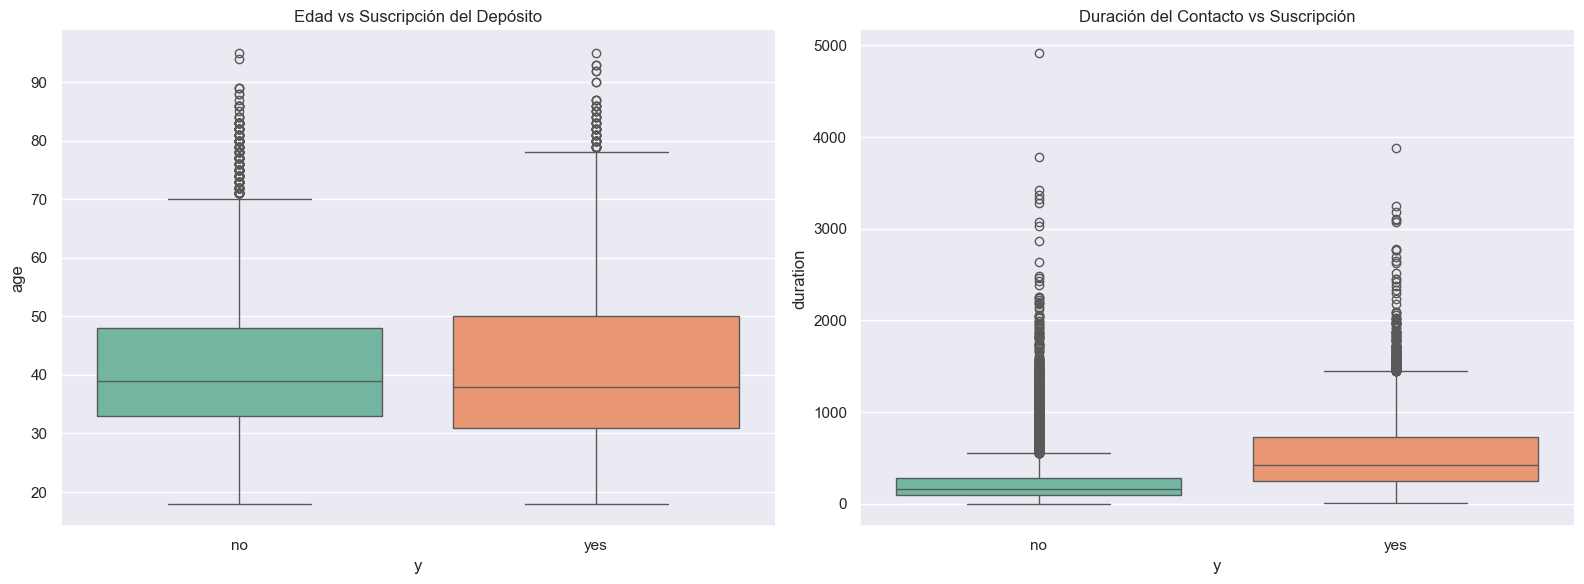

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='y', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Edad vs Suscripción del Depósito')

sns.boxplot(x='y', y='duration', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Duración del Contacto vs Suscripción')

plt.tight_layout()
plt.show()


> ⚠️ **Peligro Analítico: La variable `duration` (Data Leakage)**
> La duración de la llamada (`duration`) es el tiempo que toma el asesor hablando con el posible cliente. Esta métrica solo se conoce *después* de que ocurrió la llamada, mismo instante en que descubrimos si aceptó (`y='yes'`). No podemos usar el futuro para predecir. **El atributo `duration` DEBE excluirse del pipeline final** de modelado pre-llamada, de lo contrario reportará resultados irreales.

### 5.4. Matriz de Correlación de Numéricas
En búsqueda de multicolinealidad estructural.

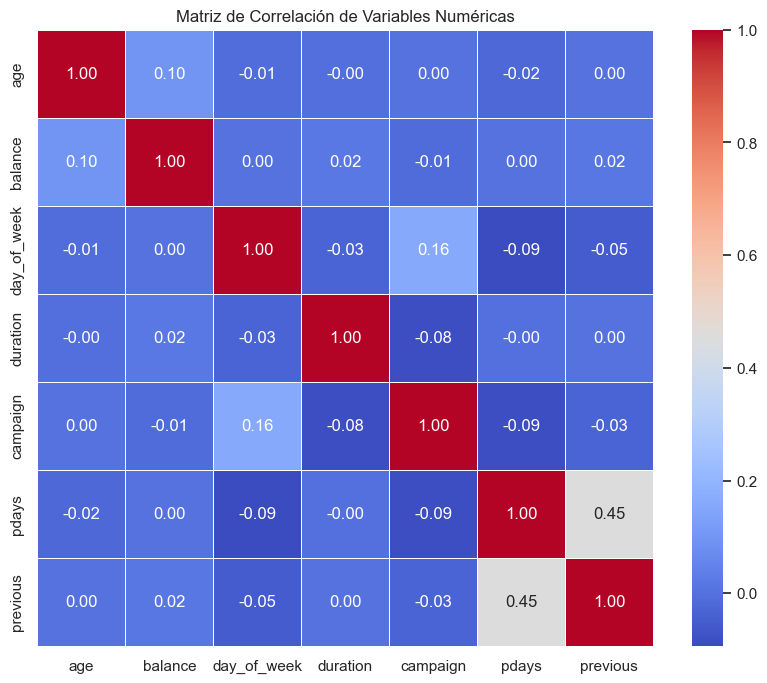

In [63]:
plot_correlation_heatmap(df)


### 5.5. Impactos Demográficos (Variables Categóricas vs Target)

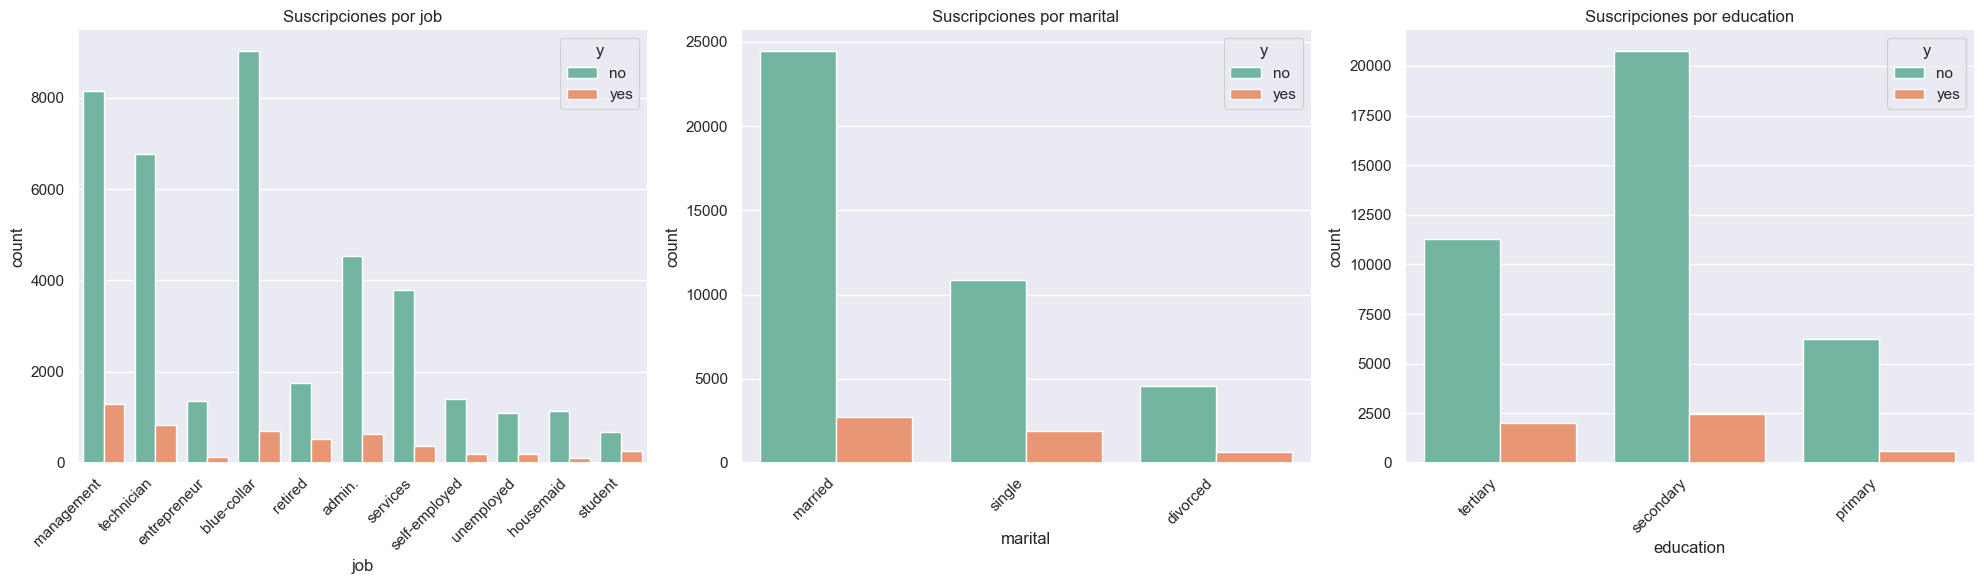

In [64]:
categorical_cols = ['job', 'marital', 'education']

plt.figure(figsize=(20, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=col, hue='y', data=df, palette='Set2')
    plt.xticks(rotation=45, ha="right")
    plt.title(f'Suscripciones por {col}')

plt.tight_layout()
plt.show()


### Conclusiones del EDA

- La clase objetivo presenta un desbalance importante: aproximadamente **88,3%** de los registros corresponden a `no` y **11,7%** a `yes`. En consecuencia, el conjunto de datos debe particionarse de forma estratificada y la evaluación del modelo no debería depender únicamente de métricas globales como `accuracy`.
- Las variables numéricas muestran distintos grados de asimetría y presencia de valores extremos, especialmente `balance`, `campaign`, `pdays` y `previous`. Este comportamiento justifica el uso de imputación y sugiere evaluar, en iteraciones posteriores, alternativas de escalado o transformación más robustas cuando el modelo sea sensible a la magnitud de las variables.
- La variable `duration` exhibe una separación aparente muy fuerte respecto a la respuesta, pero dicha señal solo está disponible durante o después de la llamada. Por tanto, su utilidad en este notebook es estrictamente descriptiva y no debe trasladarse al pipeline de un modelo operativo pre-contacto.
- Las variables `pdays` y `previous` contienen información relevante sobre el historial de campañas, pero `pdays=-1` no debe interpretarse como una magnitud temporal ordinaria. La señal más útil parece surgir de distinguir explícitamente entre clientes con y sin contacto previo, lo que respalda la creación de una variable indicadora complementaria.
- Las variables categóricas (`job`, `marital`, `education`, `month`, `contact`, `poutcome`) requieren tratamiento previo antes del modelado. Dado que sus cardinalidades son manejables y que algunas contienen faltantes potencialmente informativos, un esquema basado en imputación categórica y One-Hot Encoding constituye una base razonable para el baseline inicial.


---
## 6. Preprocesamiento Estructurado

En el procesamiento estructurado conviertimos los hallazgos del EDA en un flujo reproducible de preparación para modelado, se importan herramientas estándar de `scikit-learn`, se separan `X` e `y`, se excluye `duration` para evitar data leakage, se transforma `pdays=-1` en una señal interpretable, se realiza un split estratificado por el desbalance del target, se separan variables numéricas y categóricas, y se define un `ColumnTransformer` que imputa, escala y codifica usando solo el conjunto de entrenamiento antes de transformar el conjunto de prueba.


### 6.1. Usar piezas estándar de scikit-learn

Antes de construir el pipeline se importan herramientas de `scikit-learn` para que el preprocesamiento quede expresado como objetos reutilizables y no como transformaciones manuales sueltas. Esto importa porque más adelante podremos conectar exactamente el mismo `preprocessor` con cualquier modelo dentro de un `Pipeline`, evitando diferencias entre entrenamiento, validación y predicción.

Esta celda no transforma datos; solo prepara las clases necesarias para dividir el dataset, imputar faltantes, escalar numéricas, codificar categóricas y combinar todo con `ColumnTransformer`.


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


### 6.2. Construir la matriz de modelado sin leakage

Aquí se define qué columna es el target (`y`) y qué columnas deben excluirse antes de modelar. La exclusión crítica es `duration`, porque la duración de la llamada solo se conoce durante o después del contacto; usarla para predecir antes de llamar produciría métricas artificialmente altas.

También se codifica el target como binario: `no -> 0` y `yes -> 1`. Esto deja el problema listo para clasificadores de scikit-learn y facilita calcular tasas positivas, métricas de recall, precision, F1 y curvas ROC/PR.

Además se crea `was_previously_contacted`, una variable binaria que captura si el cliente tuvo contacto previo. Luego `pdays=-1` se reemplaza por `NaN`, porque `-1` no representa una cantidad de días real sino ausencia de contacto previo. Así el pipeline puede imputarlo de forma coherente.


In [66]:
TARGET_COL = "y"
LEAKAGE_COLS = ["duration"]
TEST_SIZE = 0.20


def build_model_frame(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Construye X/y para modelado pre-llamada evitando leakage."""
    X_model = df.drop(columns=[TARGET_COL] + LEAKAGE_COLS).copy()
    y_model = df[TARGET_COL].map({"no": 0, "yes": 1})

    X_model["was_previously_contacted"] = (X_model["pdays"] != -1).astype(int)
    X_model["pdays"] = X_model["pdays"].replace(-1, np.nan)

    return X_model, y_model


X_model, y_model = build_model_frame(df)

print(f"Columnas excluidas por leakage: {LEAKAGE_COLS}")
print(f"Dimensión de X_model: {X_model.shape}")
print("Distribución del target codificado:")
display(y_model.value_counts(normalize=True).rename({0: "no", 1: "yes"}) * 100)


Columnas excluidas por leakage: ['duration']
Dimensión de X_model: (45211, 16)
Distribución del target codificado:


y
no    88.302
yes   11.698
Name: proportion, dtype: float64

### 6.3. Usar split estratificado

El EDA mostró que la clase positiva (`yes`) es minoritaria, cerca del 11,7%. Si se hace una partición aleatoria simple, el conjunto de prueba podría quedar con una proporción distinta de positivos y la evaluación sería menos estable.

Por eso se usa `stratify=y_model`: mantiene aproximadamente la misma distribución de clases en train y test. También se fija `random_state=SEED` para que la partición sea reproducible. El conjunto de prueba se reserva desde este punto y no debe influir en decisiones posteriores.


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_model
)

split_summary = pd.DataFrame({
    "n_rows": [len(X_train), len(X_test)],
    "positive_rate": [y_train.mean(), y_test.mean()]
}, index=["train", "test"])

print("Resumen del split estratificado:")
display(split_summary)


Resumen del split estratificado:


,n_rows,positive_rate
train,36168,0.117
test,9043,0.117


### 6.4. Separar variables numéricas y categóricas

Las columnas numéricas y categóricas necesitan tratamientos diferentes. Las numéricas pueden imputarse con mediana y escalarse; las categóricas necesitan imputación textual y encoding.

Esta celda detecta los grupos usando los tipos de datos de `X_train`, no de todo el dataset. Es una práctica más limpia porque el conjunto de entrenamiento debe gobernar las decisiones del pipeline. En este caso también se incluyen columnas de tipo `string` para mantener compatibilidad con versiones recientes de pandas.


In [68]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print_section("FEATURES PARA PREPROCESAMIENTO")
print(f"Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Categóricas ({len(categorical_features)}): {categorical_features}")



                             FEATURES PARA PREPROCESAMIENTO                             
Numéricas (7): ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous', 'was_previously_contacted']
Categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 6.5. Definir un preprocessor único y reutilizable

El `ColumnTransformer` junta dos pipelines:

- **Numérico**: `SimpleImputer(strategy="median")` rellena faltantes usando la mediana del entrenamiento, una opción robusta frente a outliers como los observados en `balance`, `campaign`, `pdays` y `previous`. Luego se usa `StandardScaler` como primera versión base: centra y escala las variables para modelos sensibles a magnitudes, como regresión logística o SVM, pero no pretende resolver por completo la asimetría fuerte de `balance`.
- **Categórico**: `SimpleImputer(strategy="constant", fill_value="missing")` conserva los faltantes como una categoría explícita, útil en columnas como `poutcome` y `contact`, donde el faltante puede contener señal. Después `OneHotEncoder(handle_unknown="ignore")` convierte categorías en columnas binarias y evita errores si en test aparece una categoría no vista en train.

Se usa `remainder="drop"` para que solo pasen columnas declaradas explícitamente. Esto reduce el riesgo de colar variables no revisadas, especialmente columnas de leakage. Las alternativas robustas para `balance`, como `PowerTransformer`, `RobustScaler`, `signed_log1p` o winsorización controlada, quedan documentadas como experimentos posteriores que deben compararse contra este baseline inicial.


In [69]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", one_hot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 6.6. Ajustar con train y transformar test

El preprocessor se ajusta con `fit_transform(X_train)`, lo que significa que medianas, escalas y categorías se aprenden únicamente del conjunto de entrenamiento. Luego `transform(X_test)` aplica esas mismas reglas al conjunto de prueba sin recalcular nada.

Este patrón evita data leakage de preprocesamiento. Si se calcularan imputaciones, escalas o categorías usando todo el dataset antes del split, el test dejaría de representar datos realmente no vistos.

La salida final son matrices numéricas listas para modelos: `X_train_prepared` y `X_test_prepared`, junto con `y_train` y `y_test`. También se extraen `feature_names` para poder interpretar qué columnas resultaron del encoding.


In [70]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f"X_train_prepared: {X_train_prepared.shape}")
print(f"X_test_prepared:  {X_test_prepared.shape}")
print(f"Número final de variables después del encoding: {len(feature_names)}")
print("Primeras variables transformadas:")
display(pd.Series(feature_names).head(20))


X_train_prepared: (36168, 51)
X_test_prepared:  (9043, 51)
Número final de variables después del encoding: 51
Primeras variables transformadas:


0                          age
1                      balance
2                  day_of_week
3                     campaign
4                        pdays
5                     previous
6     was_previously_contacted
7                   job_admin.
8              job_blue-collar
9             job_entrepreneur
10               job_housemaid
11              job_management
12                 job_missing
13                 job_retired
14           job_self-employed
15                job_services
16                 job_student
17              job_technician
18              job_unemployed
19            marital_divorced
dtype: str